# Lab Report of Group 1 (Wörner, Velez, Northe)

The source code and the binaries from the spectrum analyzer from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab2_Spectrum_Analysis).

### Our used imports

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Our used helper functions to keep the code short

## 4.1 Task 1: Amplitude Modulation

**Used Settings on Signal Analyzer**

$VBW = 100Hz$ <br>
$RBW = 3kHz$ <br>
$f_c = 2GHz$ <br>
$N_{sample} = 400$

The following images show the configuration used to capture and visualize the AM signal:

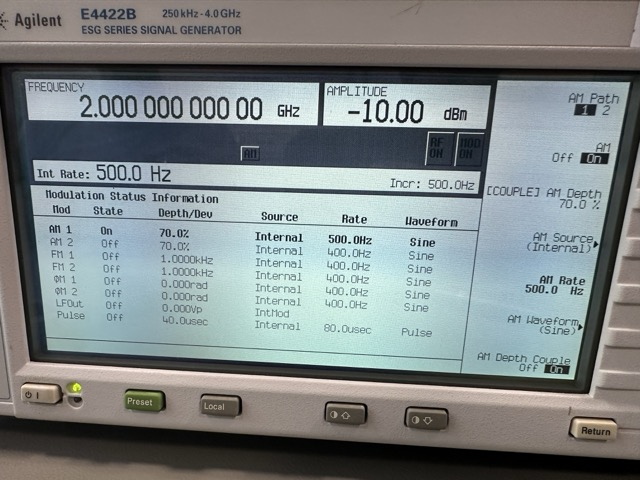
*Figure 1: Signal generator configured for a 2 GHz carrier frequency, 500 Hz modulation frequency, and 70% AM depth.*

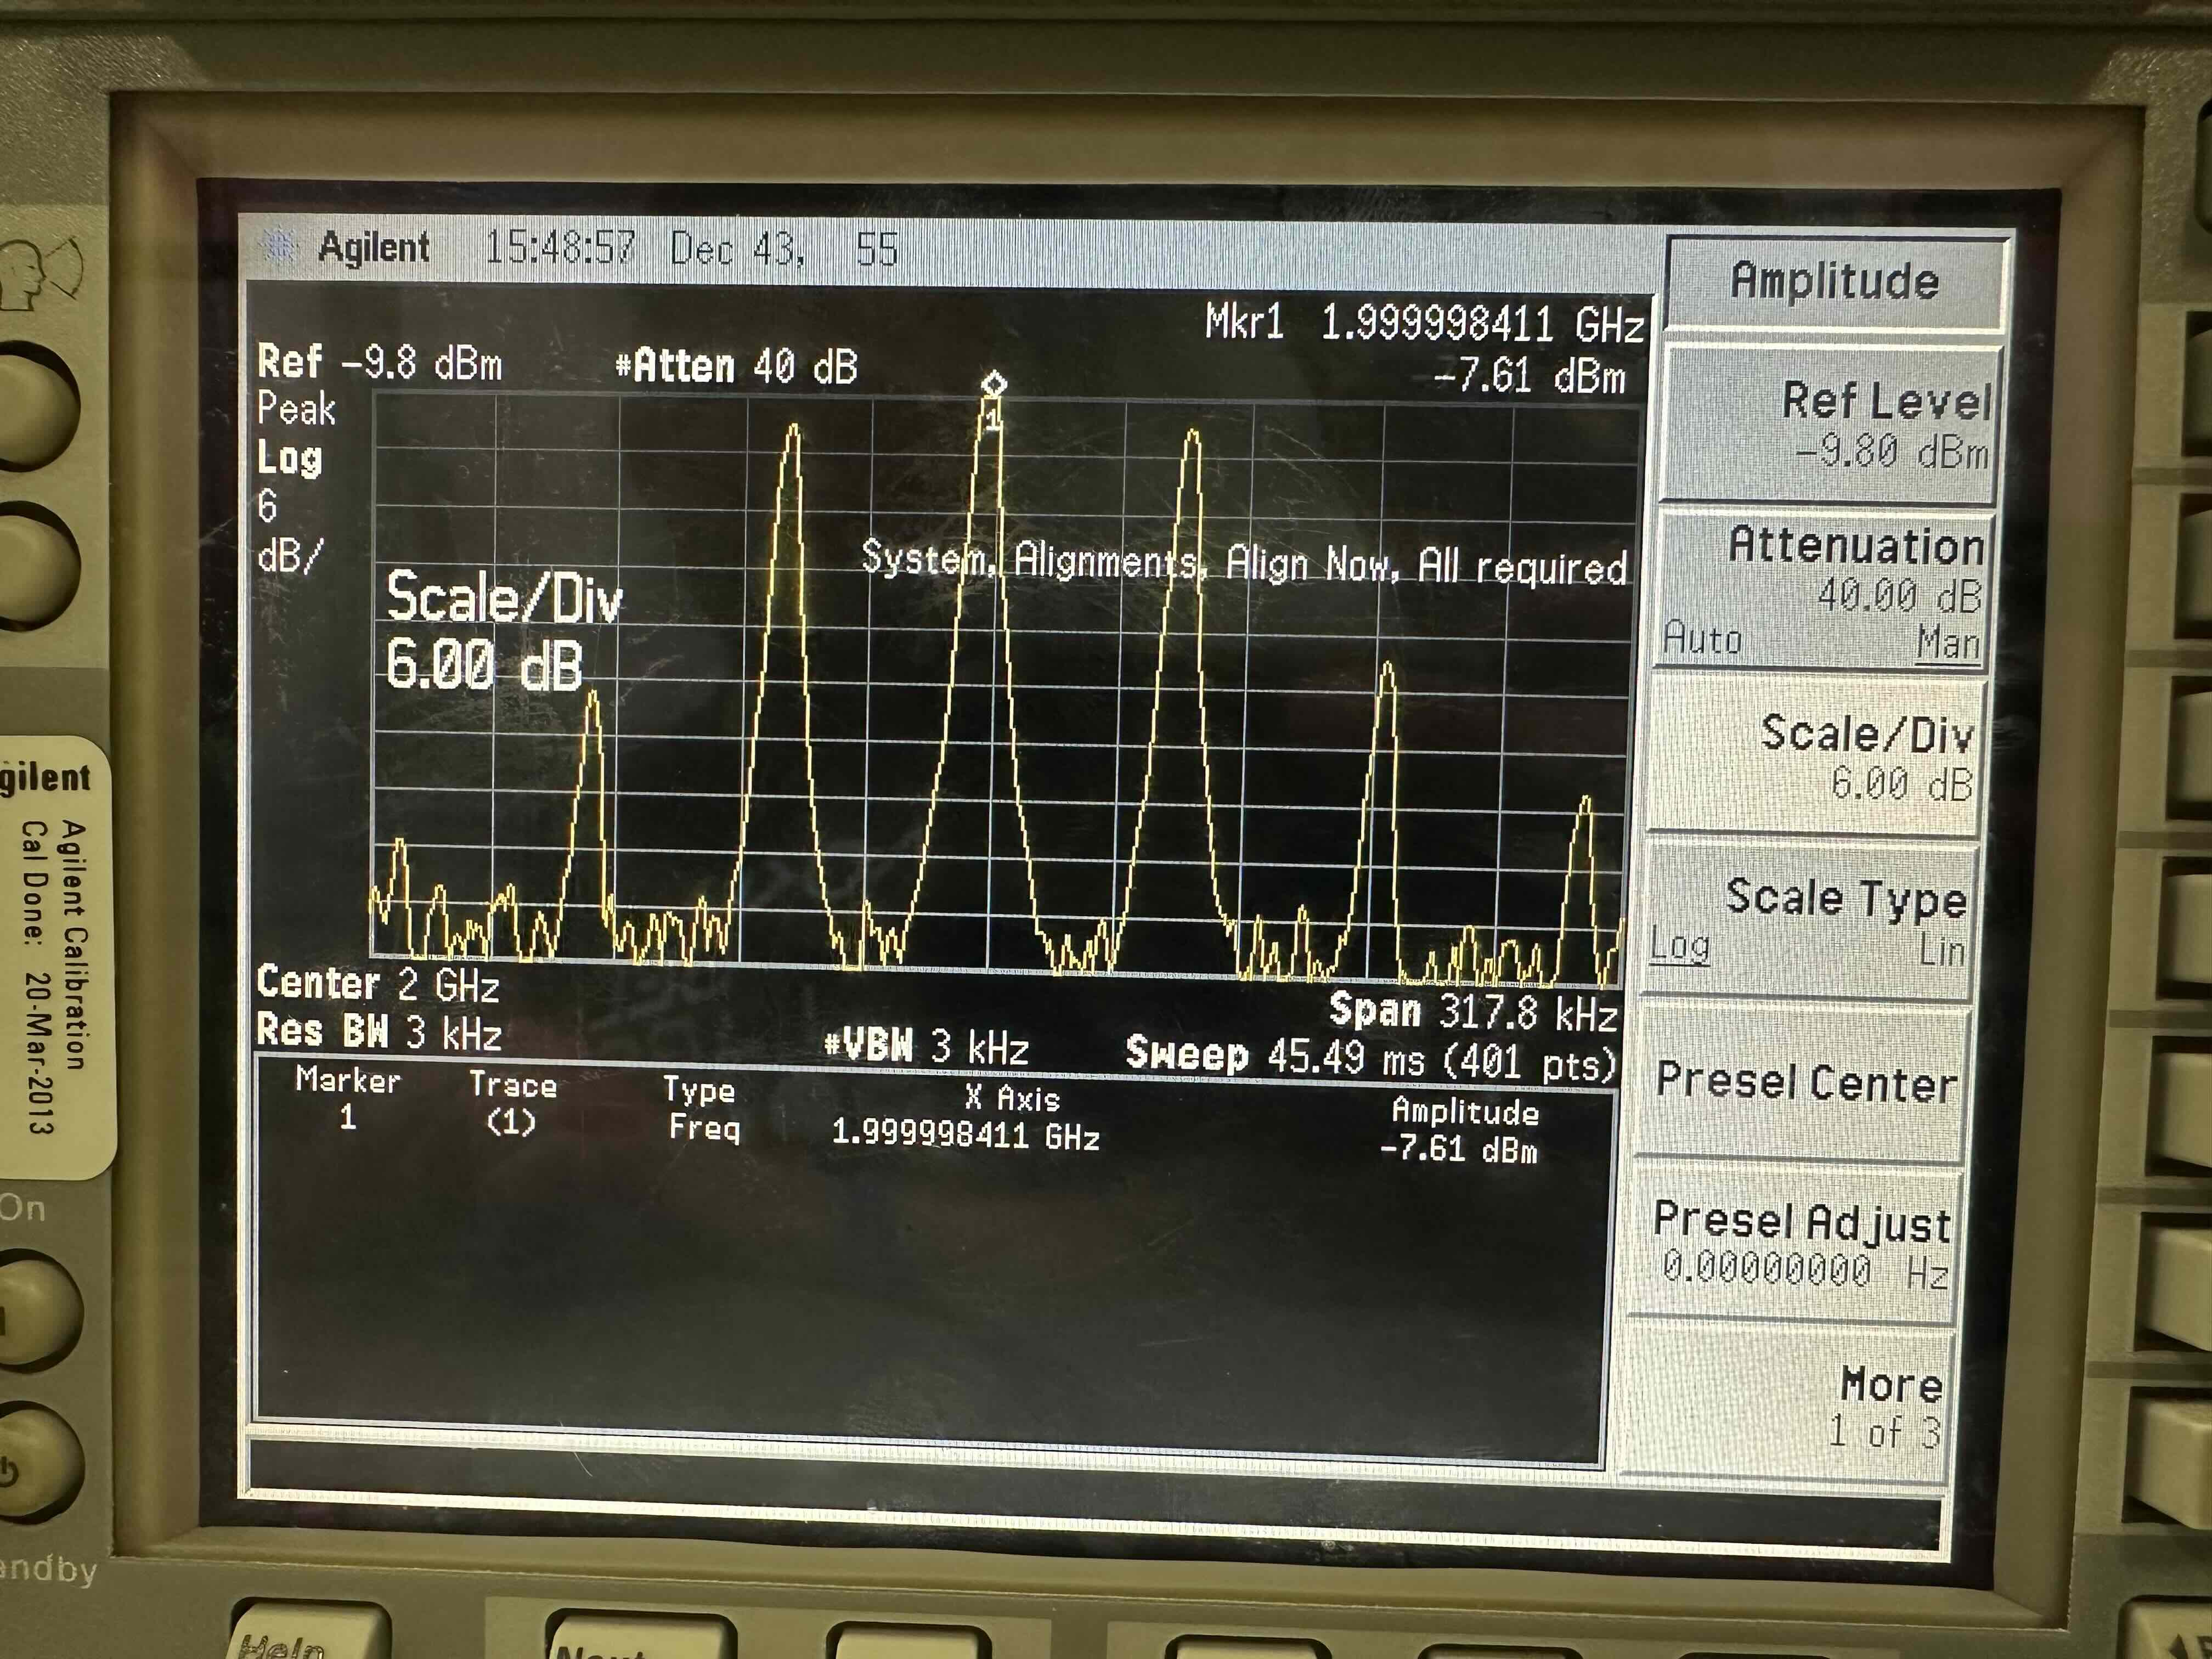
*Figure 2: Spectrum analyzer displaying the AM signal with visible carrier and sidebands. The sideband spacing is consistent with the 500 Hz modulation frequency.*

**Observation:** <br>
We noticed more than one sideband pair, when setting the output power of the signal generator to $-10dBm$. This was not present when lowering it to $-50dBm$ as one can see in the screenshots below. <br>
We suspect that there are non-linear behaviors in either the signal generators, as we tried with both available to exclude any faults in one of them, or the signal analyzer. <br>
In the screenshot with the lower signal level, we can observe the expected spectrum with one strong main carrier peak and two symmetric and equally powered sideband peaks.

**Observation:** <br>
To investigate the effect of signal amplitude on spectral visibility, the output power of the signal generator was reduced from –10 dBm to –50 dBm. All other settings (carrier frequency, modulation frequency, and modulation index) were kept the same.

At this much lower power level, the sidebands became significantly weaker, and only two narrow spikes remain in the spectrum. These correspond to the AM modulation sidebands.

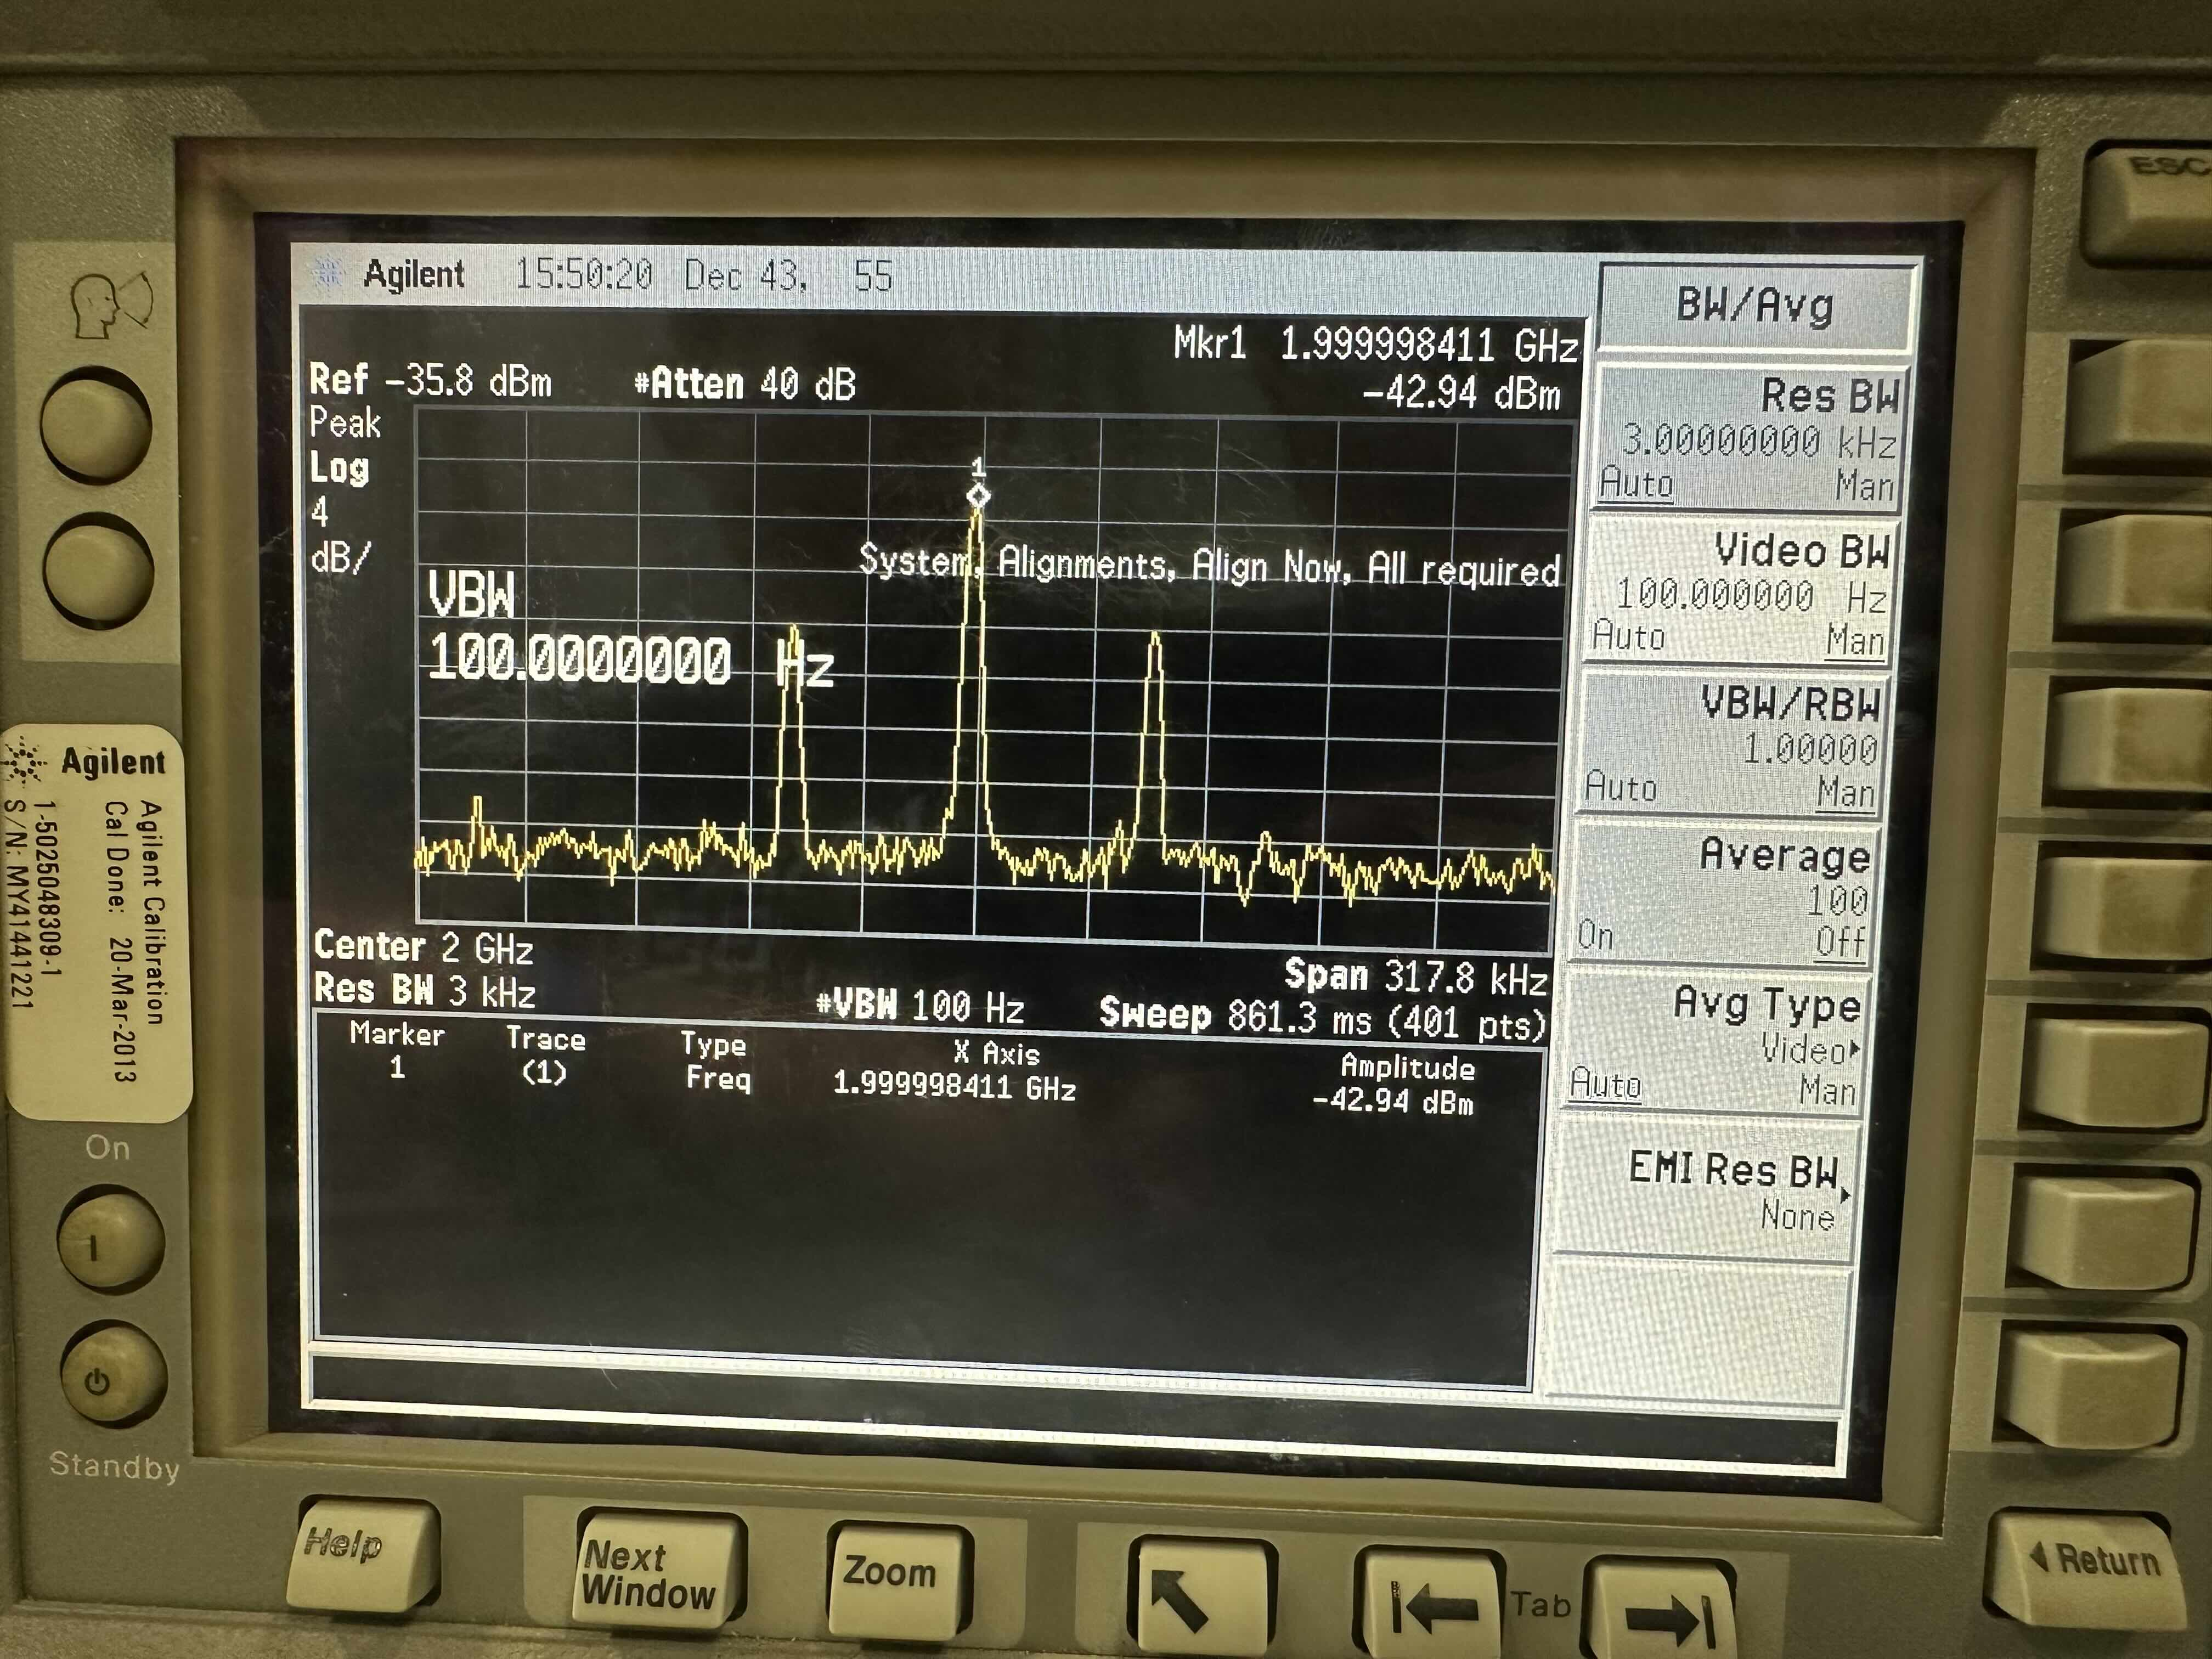 
*Figure 3: Spectrum analyzer display at –50 dBm input power. Only the AM modulation sidebands are visible.*

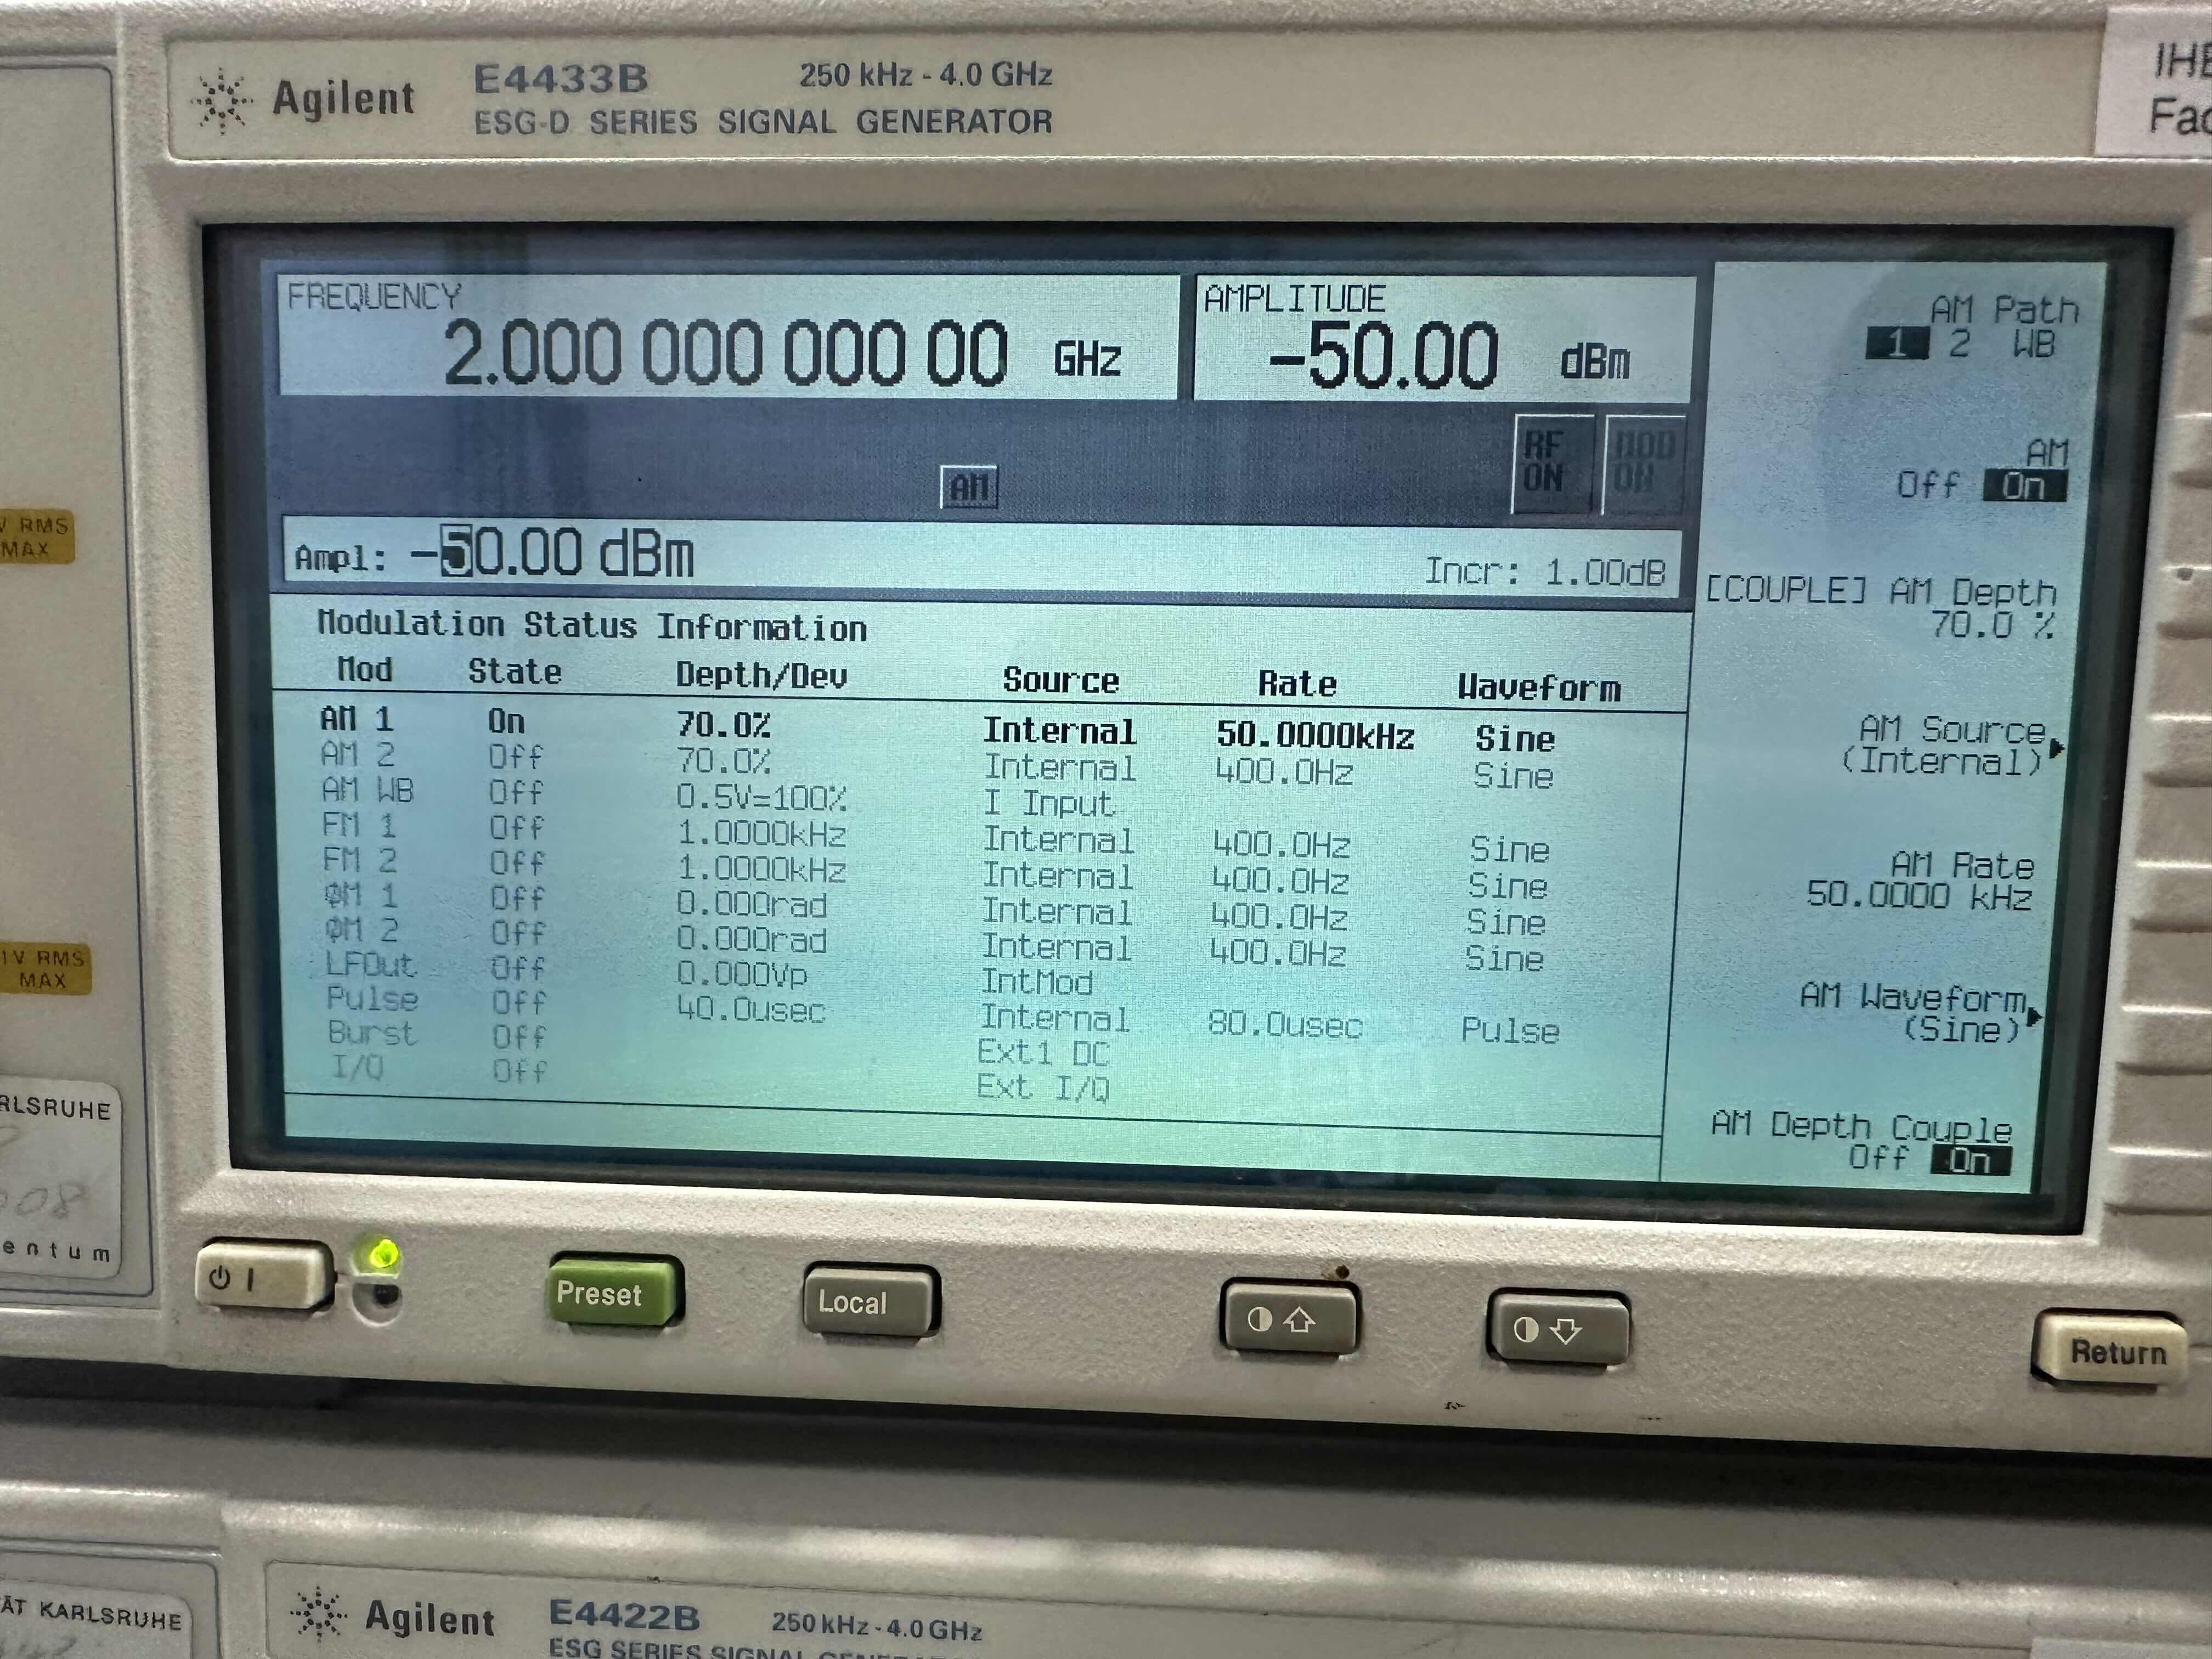
*Figure 4: Signal generator configured for 2 GHz carrier, 500 Hz modulation, 70% depth, and output power set to –50 dBm.*

### 4.1.3 Complete the following table by writing down the sideband attenuation and sideband frequencies for different values of the modulation index:

In [39]:
# Define modulation indices
modulation_indices = [0.001, 0.01, 0.25, 0.7, 1.0]

# Compute theoretical sideband levels in dB
def sideband_level(mu):
    return 20 * np.log10(mu / 2)

# Create dataframe
data = {
    "Modulation index (μ)": modulation_indices,
    "Theoretical sideband level (dB)": [round(sideband_level(mu), 2) for mu in modulation_indices]
}

df = pd.DataFrame(data)

# Display the table
print(df)


   Modulation index (μ)  Theoretical sideband level (dB)
0                 0.001                           -66.02
1                 0.010                           -46.02
2                 0.250                           -18.06
3                 0.700                            -9.12
4                 1.000                            -6.02


| Modulation index (μ) | Sideband spacing | Measured sideband level (dB) | Theoretical sideband level (dB) |
| -------------------- | ---------------- | ---------------------------- | ------------------------------- |
| 0.001                | 50.051 kHz       | -61.63                       | -66.02                          |
| 0.01                 | 50.051 kHz       | -43.40                       | -46.02                          |
| 0.25                 | 50.051 kHz       | -16.41                       | -18.06                          |
| 0.7                  | 50.051 kHz       | -7.44                        | -9.03                           |
| 1.0                  | 50.051 kHz       | -4.90                        | -6.02                           |


| Modulation Index (𝜇) | Sideband Spacing (Hz) | Sideband Level (dB) | Theoretical Sideband Level (dB) |
|----------------------|------------------------|----------------------|----------------------------------|
| 0.001                |                        |                      |                                  |
| 0.01                 |                        |                      |                                  |
| 0.25                 |                        |                      |                                  |
| 0.7                  |                        |                      |                                  |
| 1                    |                        |                      |                                  |


### 4.1.4 Using the values you determined in the previous question, plot the sideband level versus modulation index on a logarithmic plot for both the measured and the theoretical values

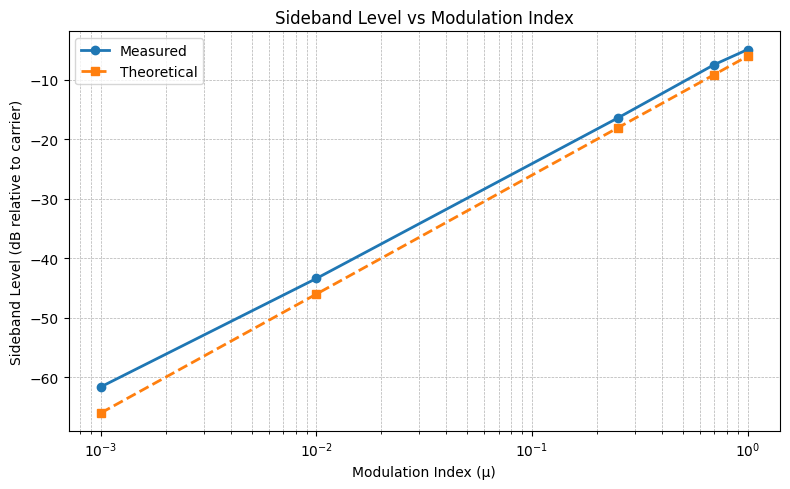

In [40]:
# Data
mu_values = np.array([0.001, 0.01, 0.25, 0.7, 1.0])
measured_levels = np.array([-61.63, -43.4, -16.41, -7.44, -4.9])
theoretical_levels = 20 * np.log10(mu_values / 2)

# Plot
plt.figure(figsize=(8, 5))
plt.semilogx(mu_values, measured_levels, 'o-', label='Measured', linewidth=2)
plt.semilogx(mu_values, theoretical_levels, 's--', label='Theoretical', linewidth=2)

# Labels and grid
plt.xlabel("Modulation Index (μ)")
plt.ylabel("Sideband Level (dB relative to carrier)")
plt.title("Sideband Level vs Modulation Index")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

### 4.1.5 Set the modulation index to 𝜇 =0.7 once more and change the modulating signal frequency to 𝑓𝑚 =500 H

To observe the AM signal in time domain, the spectrum analyser was configured in **zero span mode** following the procedure described in Section 2.2.1.5 of the lab manual:

1. The signal was tuned to the center frequency of the passband.
2. Both the resolution bandwidth (RBW) and video bandwidth (VBW) were set to **300 kHz**, which is more than twice the modulation frequency to avoid attenuation of sidebands.
3. The analyser was switched to **zero span mode**.
4. Linear display mode was selected, and the sweep time was adjusted to show several cycles of the demodulated waveform.

**Configuration Settings:**  
- Trigger: *Video*  
- Span: 476.1 μV  
- Sweep Time: 5 ms  
- Measured Period: $T = 2\ \text{ms}$

The measured period of the demodulated waveform was **2 ms**, which aligns with the expected theoretical period based on the modulation frequency:

$$
T = \frac{1}{f_m} = \frac{1}{500} = 2\ \text{ms}
$$

#### Sanity Check, if meassured frequency matches out expectation

In [41]:
T_p = 2e-3  # [s]
f_meas = 1 / T_p

print(f"{f_meas:.1f} Hz")

500.0 Hz


#### Measurement Screenshots

The following screenshots show the configuration used to capture the AM signal in zero span mode:

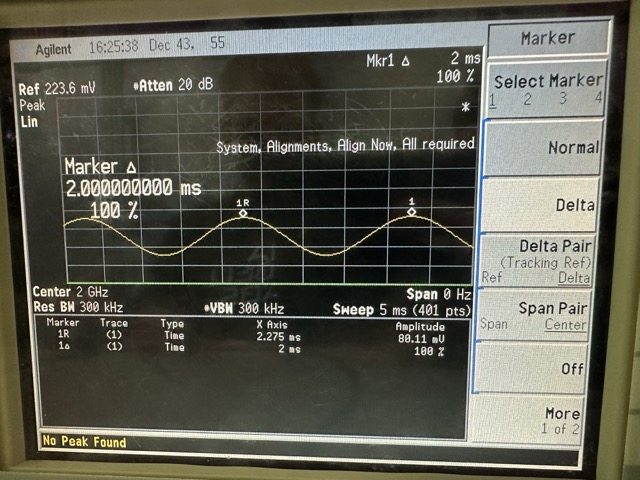
*Figure 5: Spectrum analyzer in zero span mode showing a demodulated signal with a period of 2 ms.*

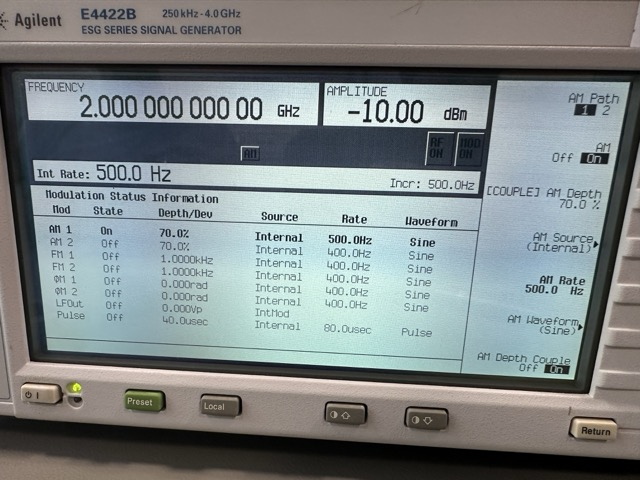
*Figure 6: Signal generator settings with a 2 GHz carrier, -10 dBm output, 500 Hz modulation frequency, and 70% AM depth.*

## 4.2 Task 2 Angle Modulation

### 4.2.2.1 & 4.2.2.2

#### Used Spectrum Analyzer Settings

- $RBW = 3kHz$
- Centre frequency $2GHz$
- Span $180kHz$
- Number of points: $400$

<img src="Screenshots/4-2-2-1-sa.jpeg" /> <br>
<img src="Screenshots/4-2-2-1-sg.jpeg" />

### 4.2.2.3 Questions

#### Describe the spectrum you can see on the spectrum analyser.

We can observe a "comb" line spectrum with stronger symmetrical sidelobes. The carrier power is noticeably lower than the adjacent sidelobes. <br>
The sidelobes are equally spaced apart by $\approx 24.3kHz$ 

#### What type of angle modulation is the signal in Question 1?

Wideband FM modulation as $1 \leq \beta < 10$

#### What is the bandwidth of the signal displayed on the spectrum analyser? How does this compare with the theoretical bandwidth value?

The spectrum observed on the analyzer showed that the sidebends were stronger than the carrier component. This is expected when the modulation index is near β = 2.4, which is close to a zero of the first-order Bessel function of the first kind, causing suppression of the carrier.

Given that β = 2, the signal falls within the range of wideband angle modulation (where $1 \leq \beta < 10 $. According to Carson’s Rule, the theoretical bandwidth is:

$$
B_{\text{FM}} = 2B(\beta + 1) = 2 \cdot 25\,\text{kHz} \cdot (2 + 1) = 150\,\text{kHz}
$$

The spectrum analyzer shows a value of $BW \approx 100.118kHz$, which is reasonably close, considering practical resolution and filter effects. The picture of the spectrum is available in Figure 7.

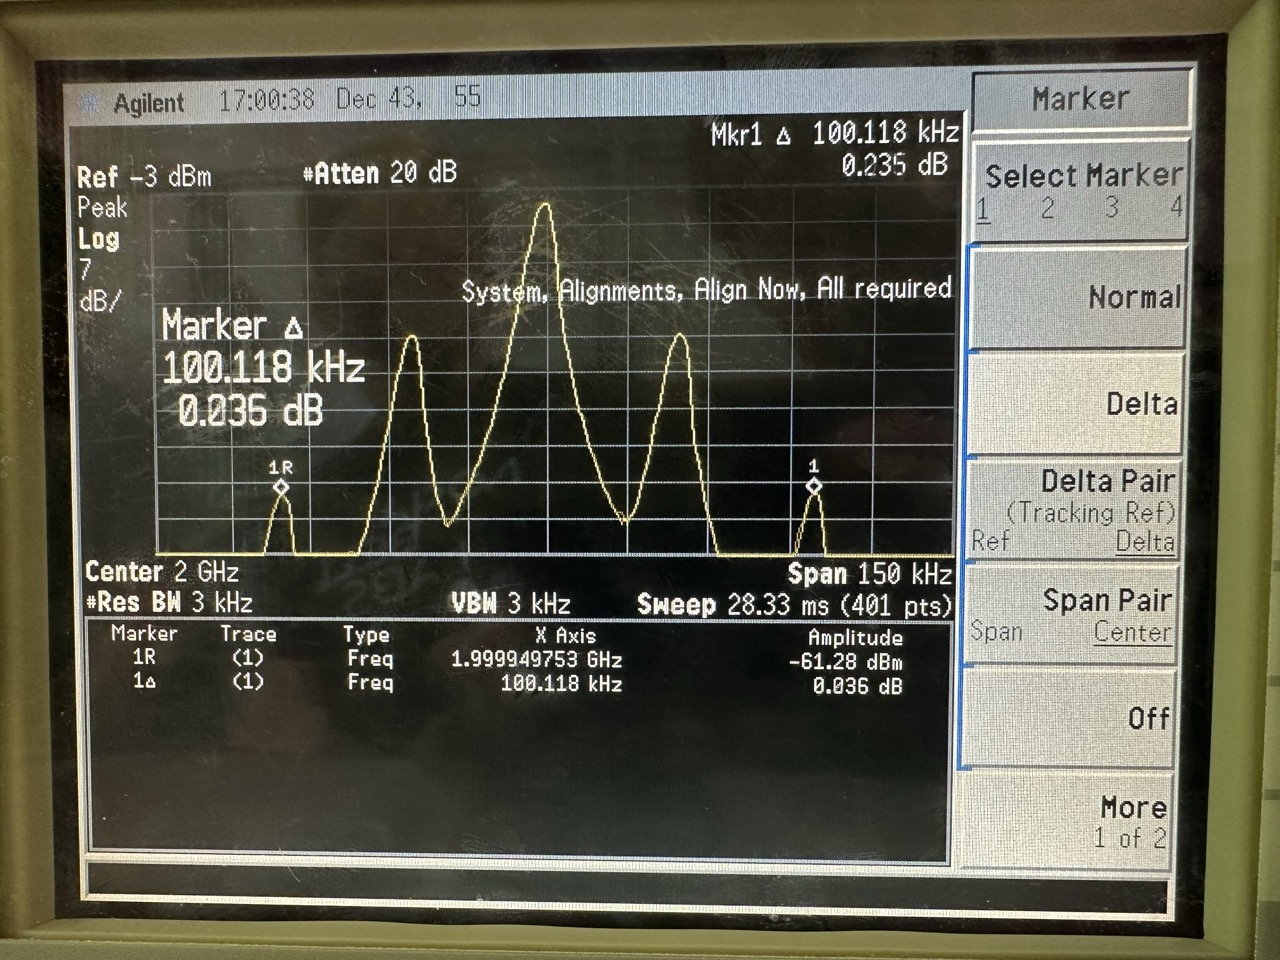
*Figure 7: Spectrum analyzer output showing the FM-modulated signal for β = 2.*

### 4.2.2.4 Change the modulation index to 𝛽 = 0.1 and answer the following questions:

#### Describe the spectrum you can see on the spectrum analyser

The spectrum shows one high peak at the carrier and very close to it the two adjacent peaks. The distance between the main and first sidelobe is$\approx 24.75kHz$. The next sidelobes are considerably smaller. 

#### What type of angle modulation is the signal in Question 4?

This is a narrowband FM signal, as $\beta < 1$

#### What is the bandwidth of the signal displayed on the spectrum analyser? How does this compare with the theoretical bandwidth value?

The observed bandwidth, observed in Figure 8 was approximately 50 kHz ($\approx 2*24.75$ kHz), covering the carrier and one sideband on each side. The theoretical bandwidth using Carson's Rule for narrowband FM is:

$$
B_{\text{FM}} \approx 2 f_m = 2 \cdot 25{,}000 = 50\,\text{kHz}
$$

The measured and theoretical bandwidth values match well, confirming the validity of the approximation for small values of $\beta$.

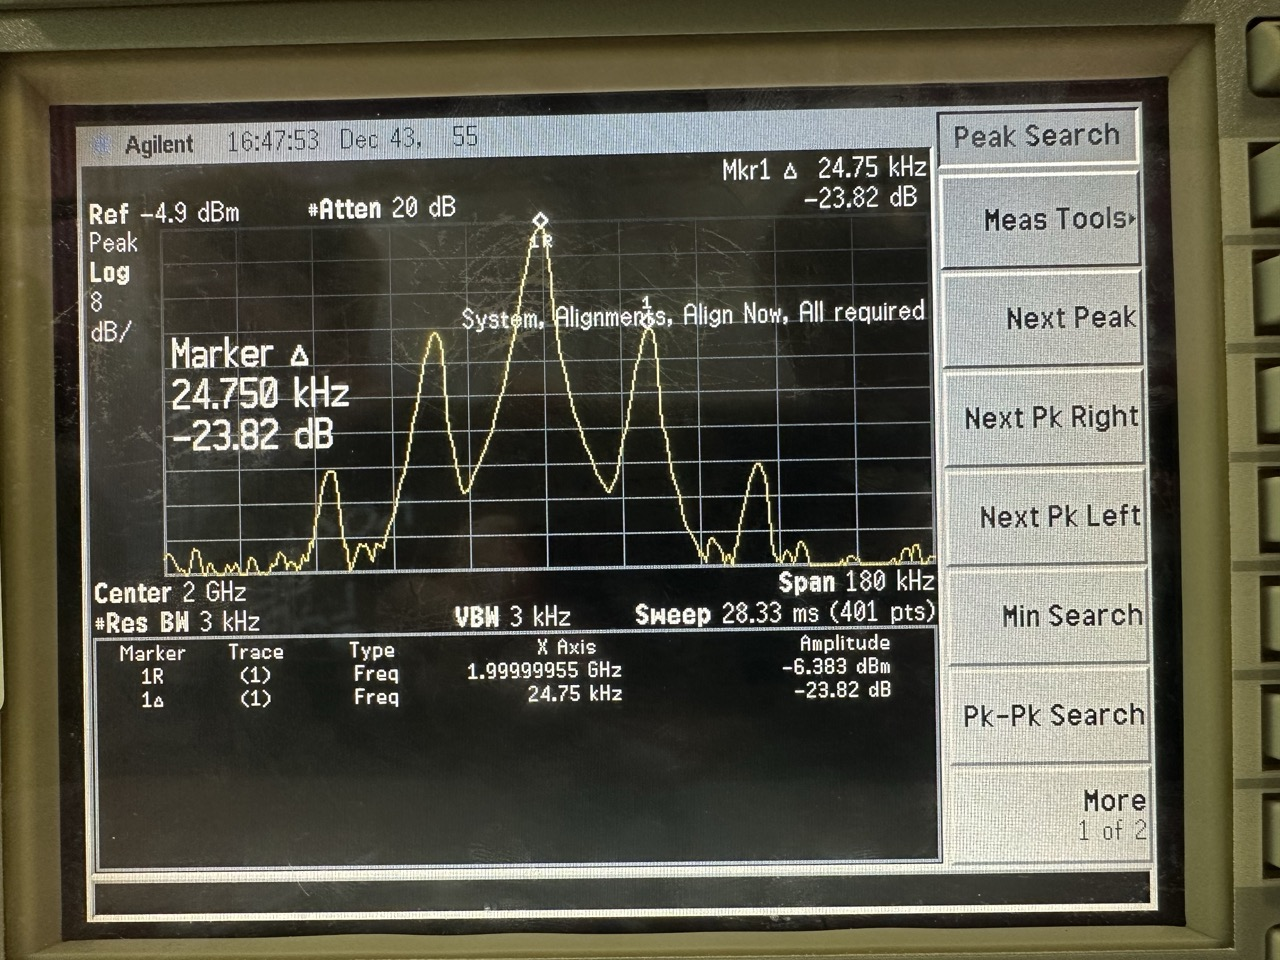
*Figure 8: Spectrum analyzer output showing the FM-modulated signal for β = 0.1.*

### 4.2.2.5 Change the modulation index to 𝛽, in order to answer the following questions

#### At what value of 𝛽 does the carrier component no longer appear in the spectrum?

The carrier would disappear according to the Besselfunction (as seen in Figure 9) at $J_0(2.4) = 0$. We could very closely match this with a value of $\beta = 2.42$

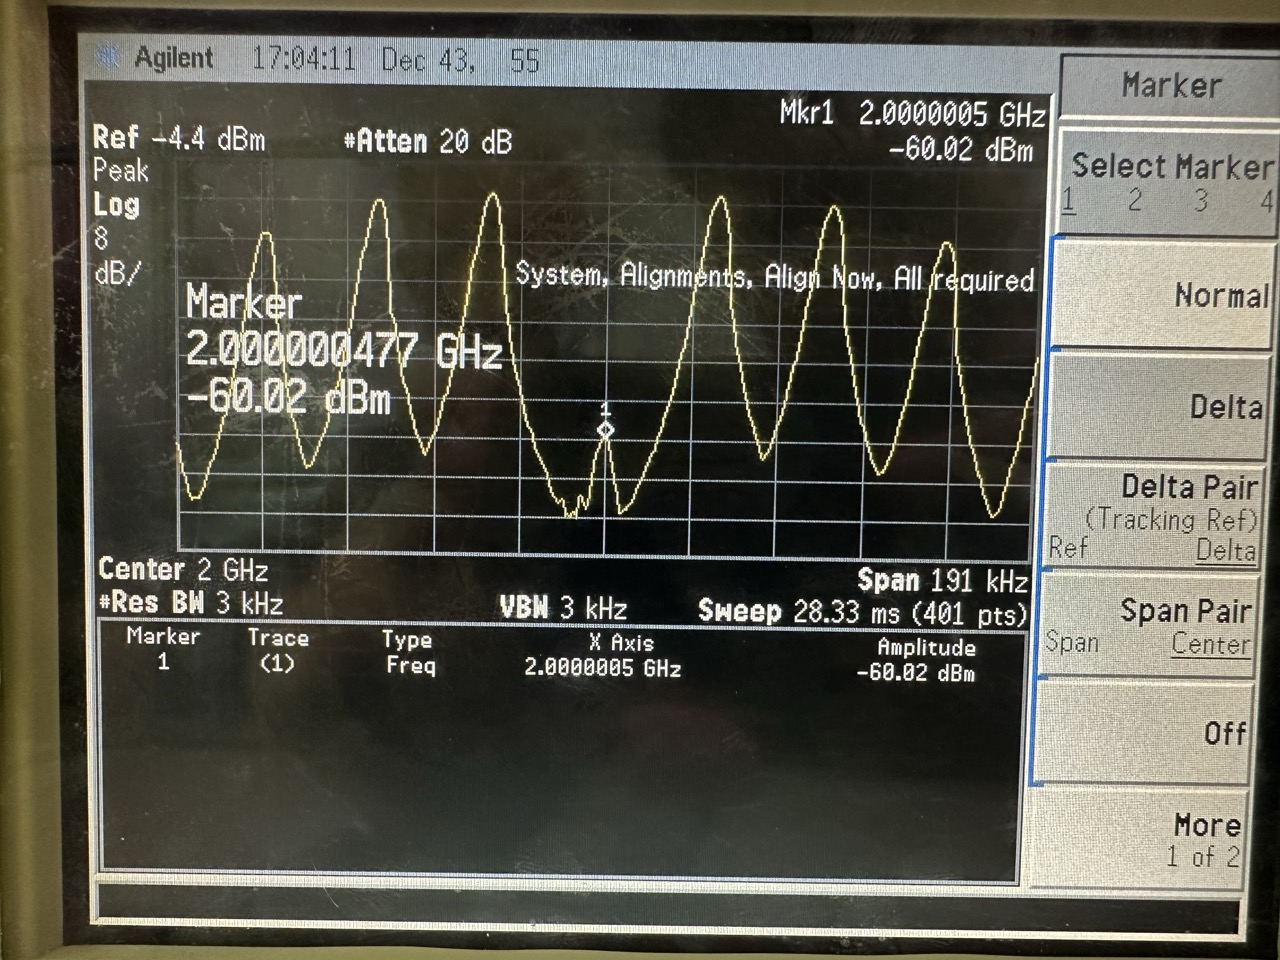
*Figure 9: Spectrum analyzer output showing the FM-modulated signal for β = 2.42. Notice that the carrier is not visible.*

#### At what value of 𝛽 does the 1st sideband components no longer appear in the spectrum?

The Besselfunction would predict this to happen at $J_1(4) = 0$. This was possibile to recreate with a value of $\beta = 3.86$

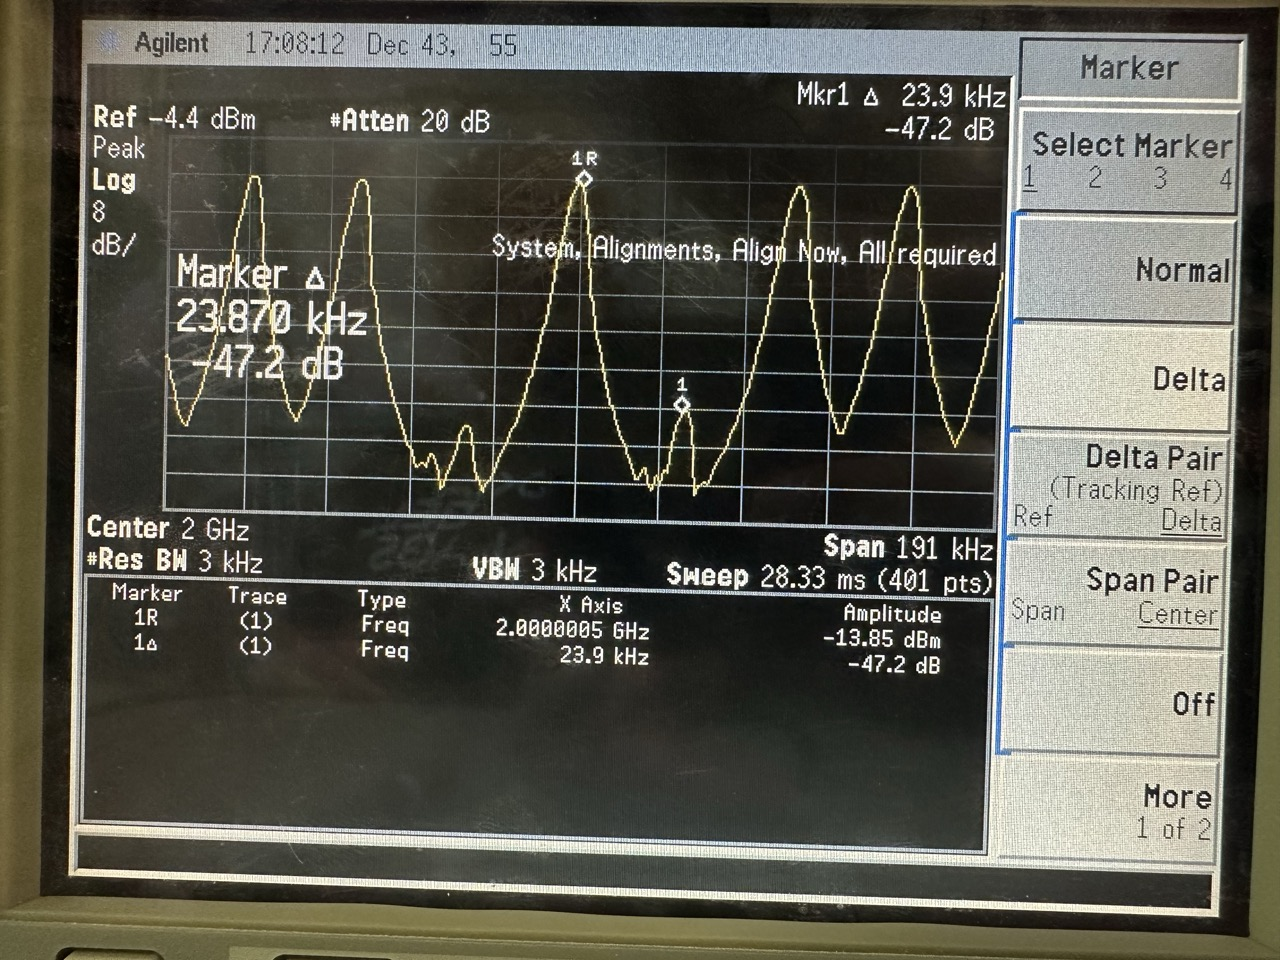
*Figure 10: Spectrum analyzer output showing the FM-modulated signal for β = 3.86. Notice that the first sideband component is not visible.*


#### What is the next value of 𝛽 where the carrier component again no longer appears in the spectrum?

The Besselfunction would predict this to happen at $J_0(\approx 5.6) = 0$. With a value of $\beta = 5.33$ we could accomplish a minimum carrier power. As seen in Figure 11 showing the spectra and Figure 12 showing the settings of the signal generator.

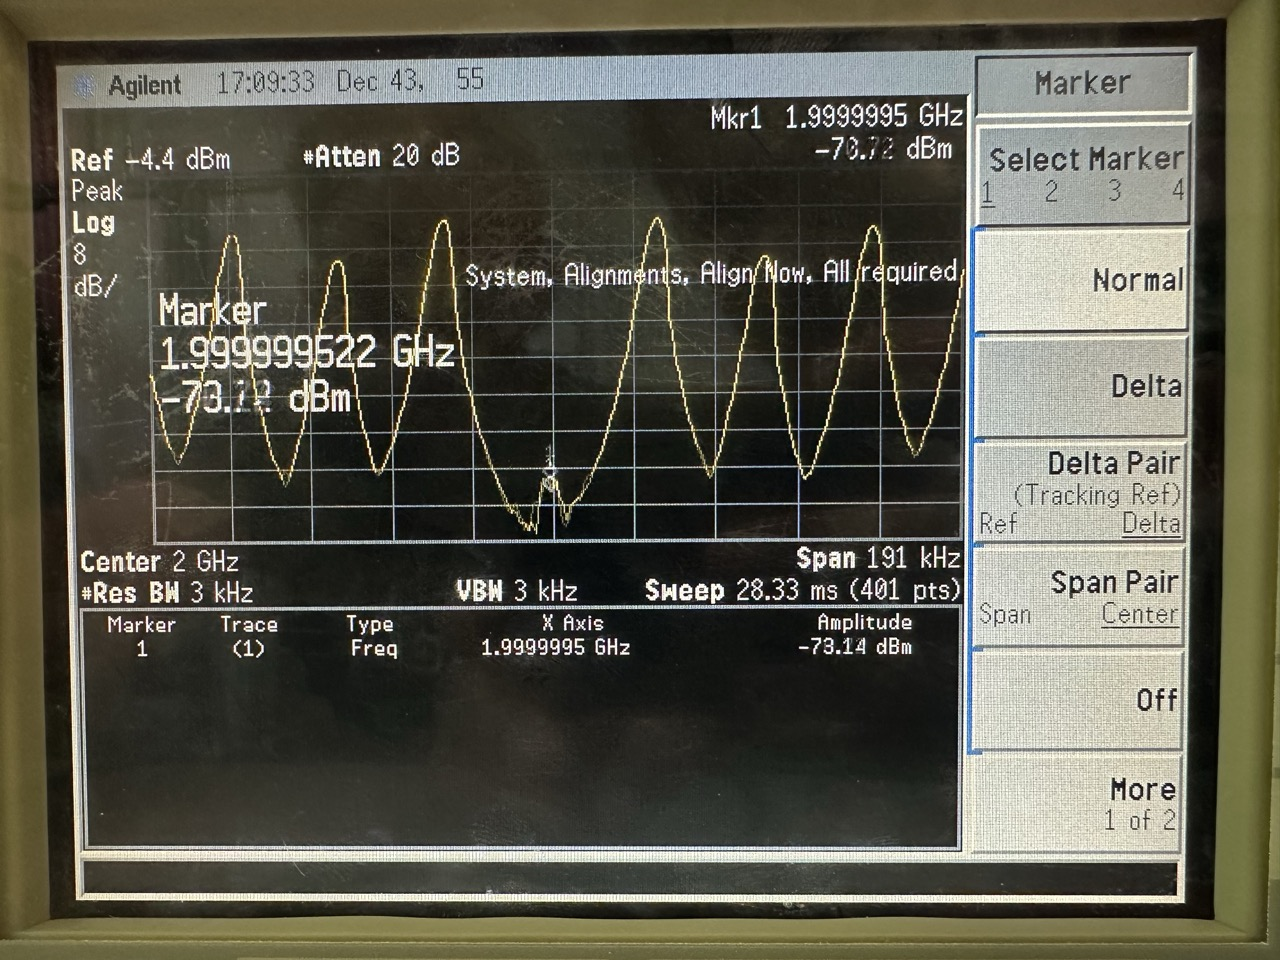
*Figure 11: Spectrum analyzer output showing the FM-modulated signal for β = 5.33. Notice that the carrier is not visible.*

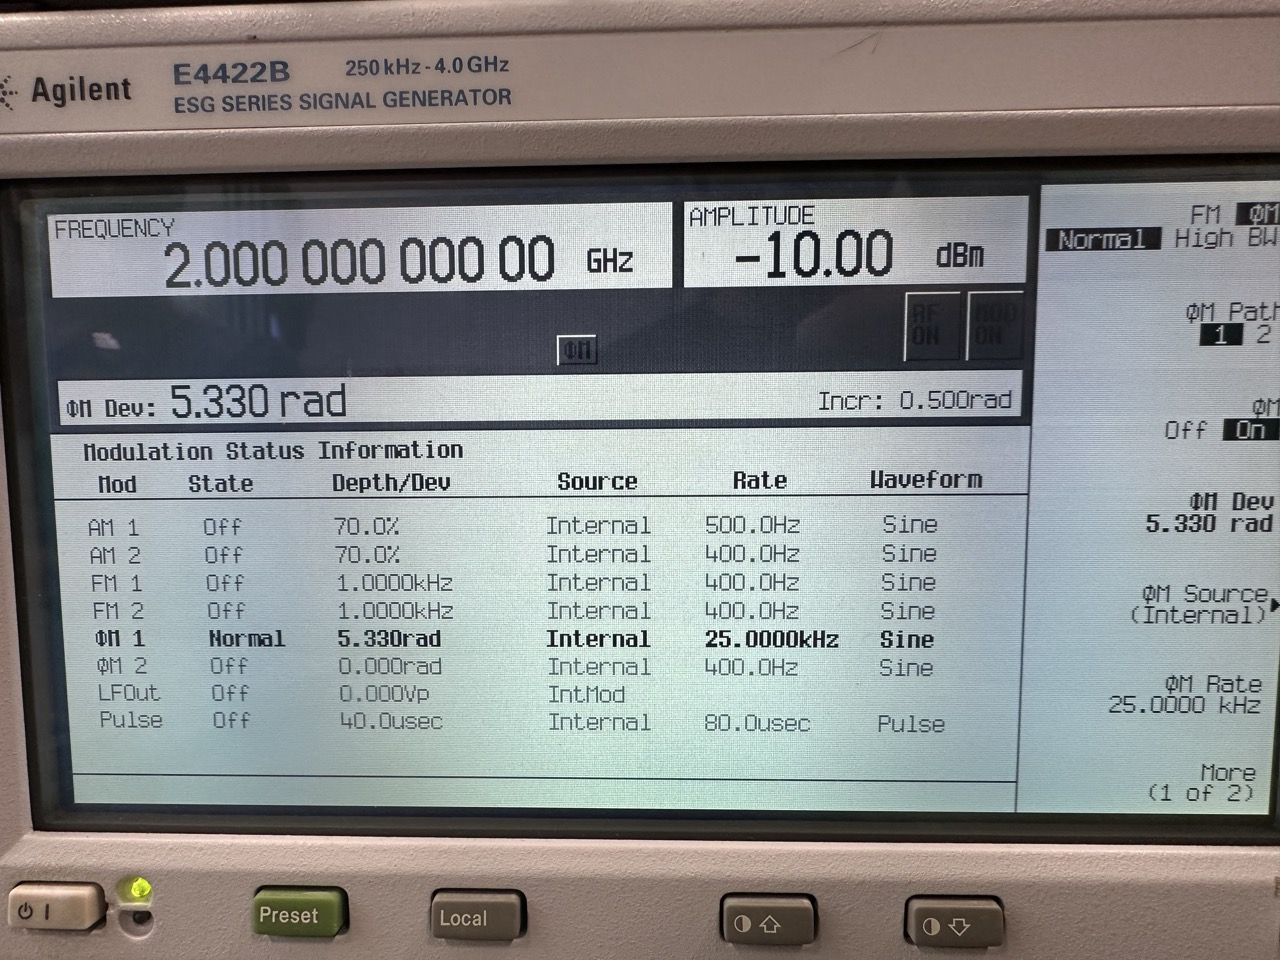
*Figure 12: Settings from the signal generator for the next value of $\beta$ where the carrier is not visible.*

### 4.2.2.6 Change the modulation index to 𝛽 = 12 and the modulating frequency to 𝑓𝑚 = 1 kHz
The parameters in the signal generator were adjusted, yielding the spectra from Figure 13.
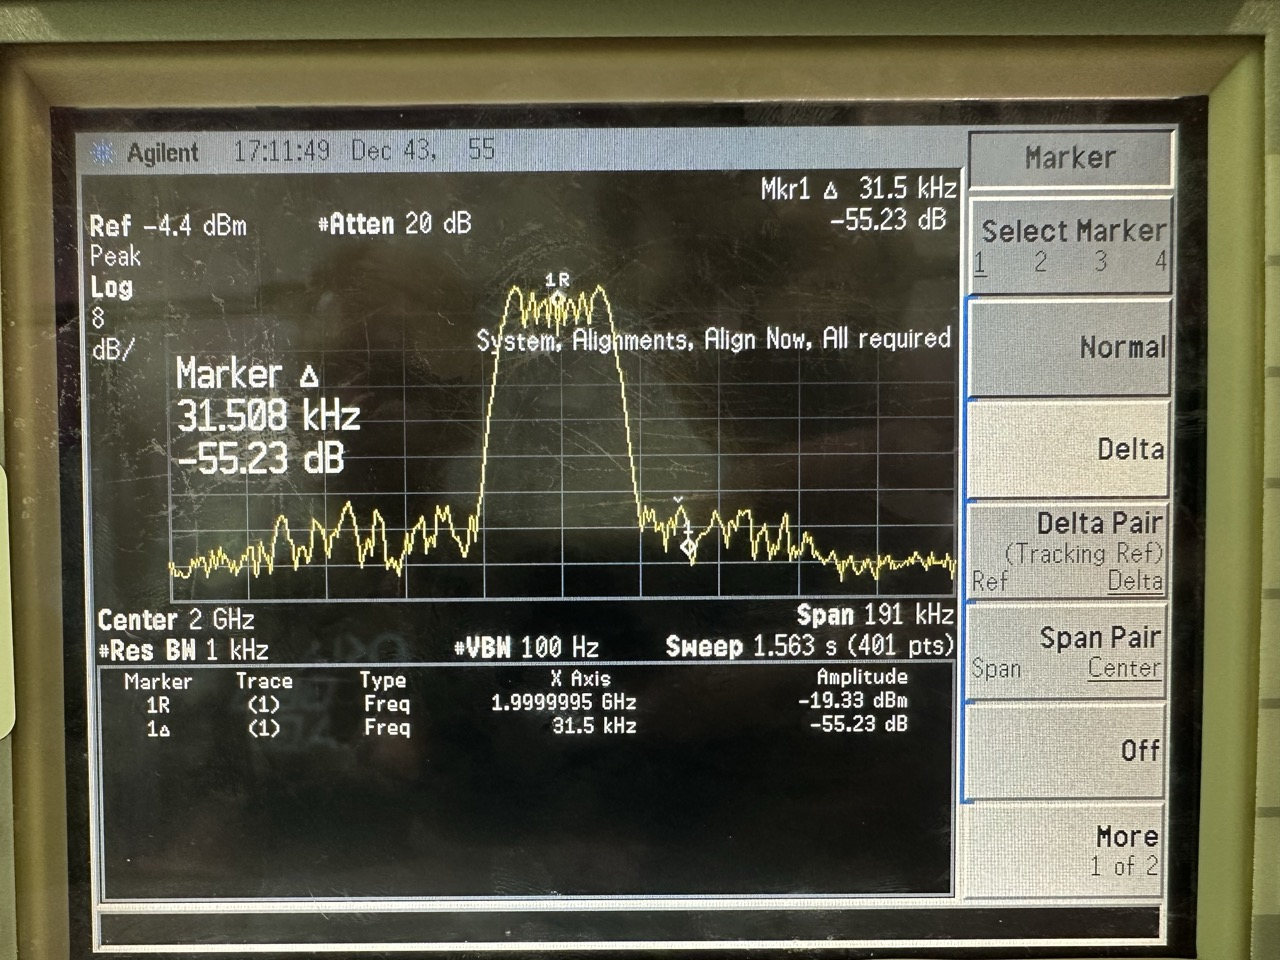
*Figure 13: Spectrum analyzer output showing the FM-modulated signal for β = 12.*

#### Describe the spectrum you can see on the spectrum analyser

We can see one big symmetrical lobe around the carrier. This big lobe has a small "comb" on top of it. <br>
There are no other sidelobes.

#### What type of angle modulation is the signal in Question 6?

We can see a ultra-wideband FM signal as $\beta > 10$

#### What is the bandwidth of the signal displayed on the spectrum analyser? How does this compare with the theoretical bandwidth value?

As it can be seen in Figure 14, the bandwidth is $25\,\text{25.8 kHz}$. Theoretical FM bandwidth can be estimated using Carson’s Rule:

$$
B_{\text{FM}} = 2 f_m (\beta + 1) = 26\,\text{kHz}
$$

The measured and theoretical values are therefore consistent within practical accuracy.



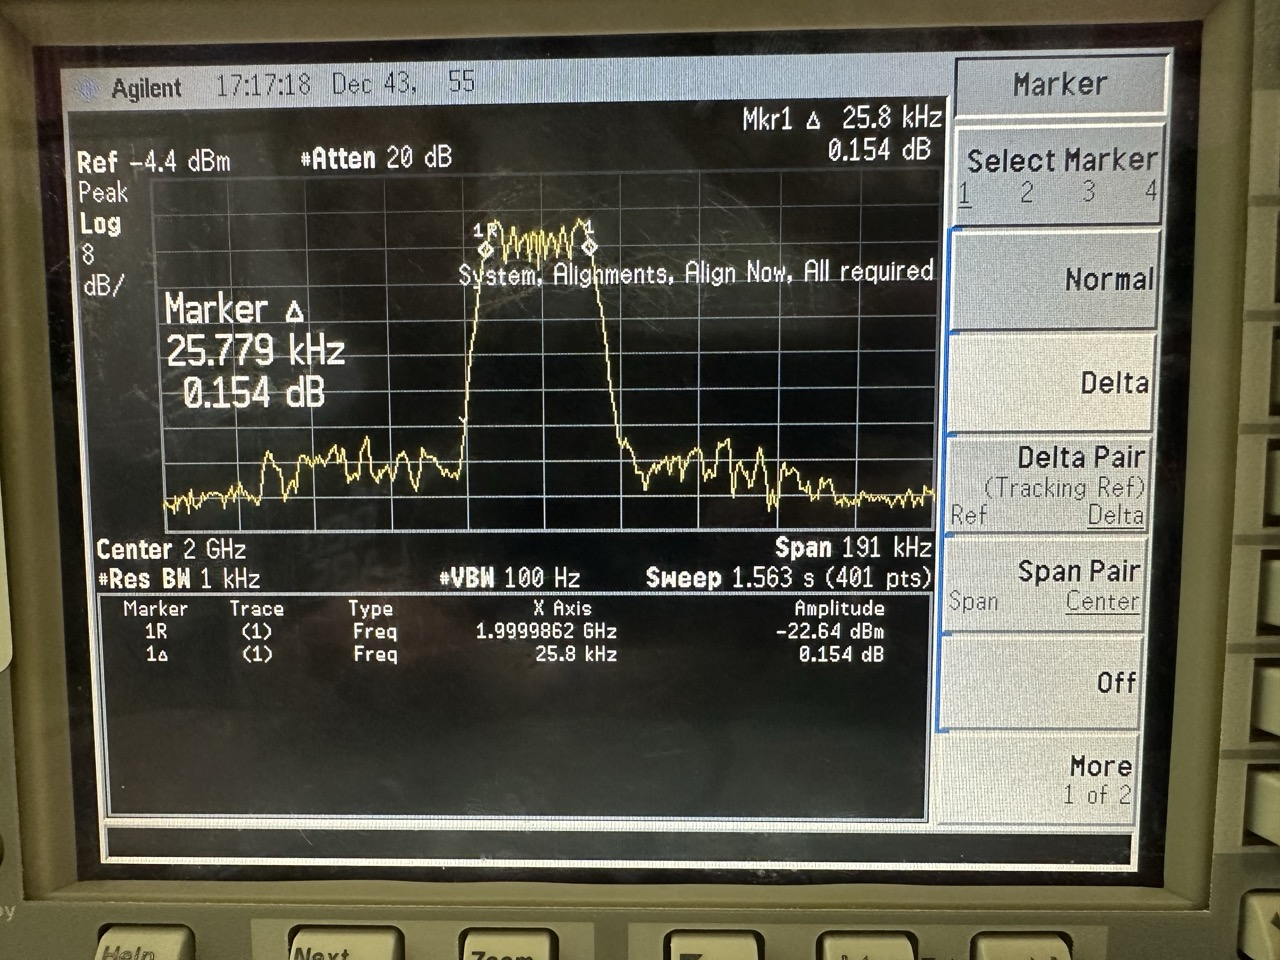
*Figure 14: Bandwidth of the FM-modulated signal for β = 12.*

## 4.3 Task 3: Pulse spectrum
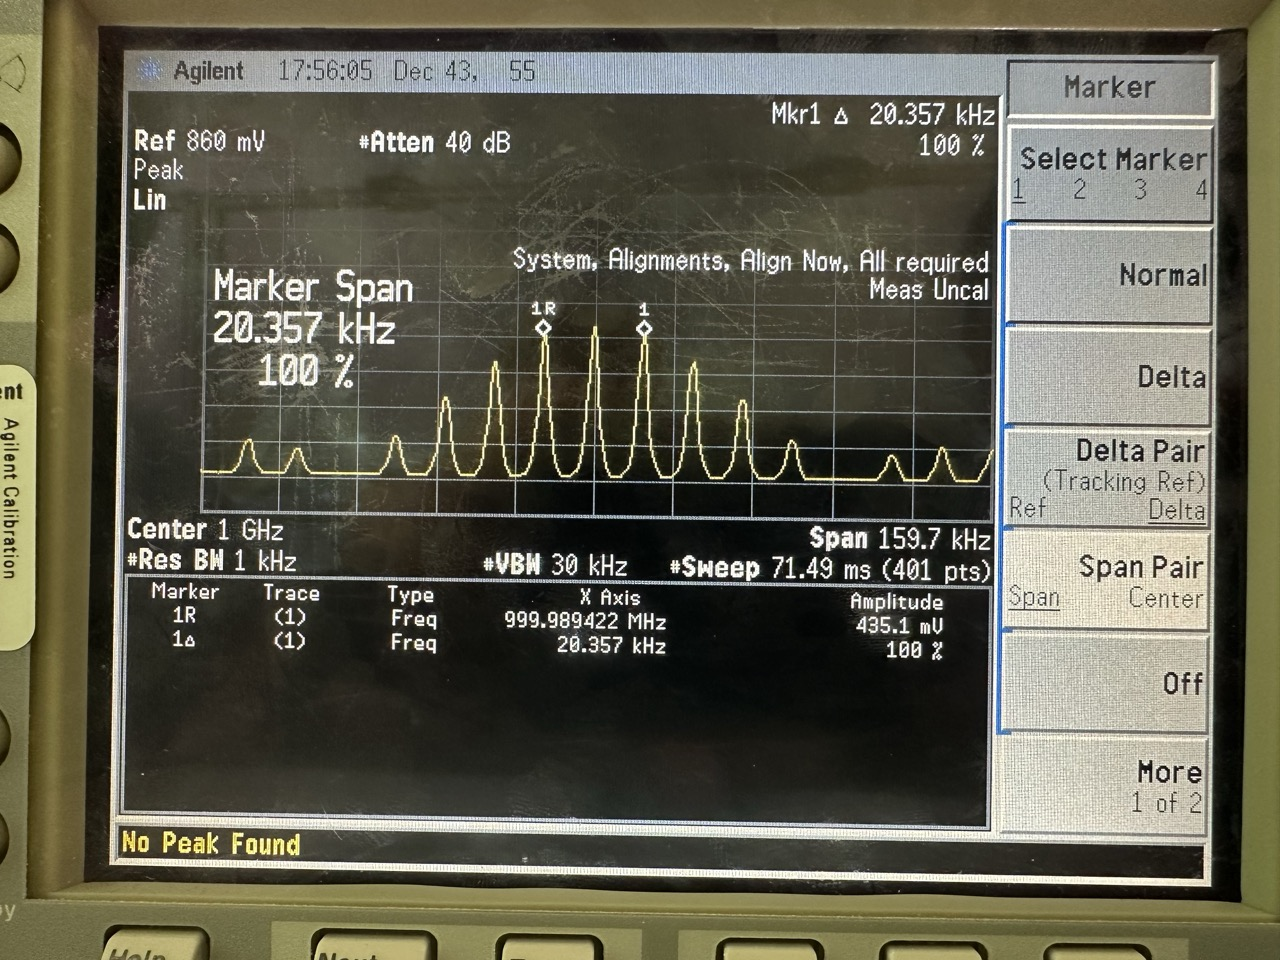
*Figure 15: Pulse spectrum.*


- Carrier frequency $f_c = 1GHz$
- Output power $P_{out} = 10dBm$
- Pulse period $T = 100 \mu s$
- Duty Cycle $20 $%

#### 4.3.3.2

$\red{\text{Insert answers}}$

### Spectrum Analysis Settings

| **Setting**        | **Envelope Spectrum** | **Line Spectrum** |
|--------------------|-----------------------|-------------------|
| RBW (Resolution Bandwidth) | Narrower (to smooth out details) | Narrow or very narrow (to resolve peaks) |
| Video Bandwidth    | Wider (for smoother display) | Narrow (to reduce noise) |
| Centre Frequency   | Set to target signal | Set to target signal |
| Span               | Wider span (to see overall envelope) | Narrow span (to zoom into harmonic components) |
| Number of Points   | Lower (coarser resolution) | Higher (finer resolution) |


**Envelope Line Spacing Parameters**
<img src="Screenshots/4-3-2-envelope-line-spacng-sa.jpeg" /> <br>

**Envelope Spectrum**

<img src="Screenshots/4-3-2-envelope-spectrum-sa.jpeg" /> <br>

**Line Spectrum**

<img src="Screenshots/4-3-2-line-spectrum-sa.jpeg" /> <br>

**Zero Span Mode**

<img src="Screenshots/4-3-2-pulse-zero-span-sa.jpeg" /> <br>

#### 4.3.3.3 Measure the line spacing and the zero spacing and compare it with the theoretical values, by completing the following table

$\red{\text{Insert answer}}$

| Spectrum         | Measured                      | Theoretical                    |
|------------------|-------------------------------|--------------------------------|
| Line Spacing      | Distance between spectral lines (as measured) | Expected line spacing based on signal properties |
| Zero Spacing      | Measured frequency spacing where spectral lines vanish | Theoretical prediction of zero points in the spectrum |


#### 4.3.3.4 Measure the level difference between the spectral lines at the carrier frequency and the first sidelobe maximum. What is this difference and why?

$\red{\text{Insert answers}}$

<img src="Screenshots/4-3-4-sinc-sa.jpeg" /> <br>

#### 4.3.3.5 Now study the influence of an increasing RBW on the amplitude for both types of spectra.

**For the line spectrum: <br>What happens to the amplitude of the line spectrum when the RBW is
increased?** <br>

$\red{\text{Insert answers}}$

**For the Envelope Spectrum** <br>

**What happens to the amplitude of the envelope spectrum when the RBW
is increased?**

$\red{\text{Insert answers}}$

**Explain this behaviour. Support your explanation with a calculation**

$\red{\text{Insert answers}}$

**Further increase the RBW – at what point does the behaviour/trend you
described in the previous question no longer happen? Why?**

$\red{\text{Insert answers}}$

## 4.4 Task 4: Mixer

- Local Oscillator (LO) frequency: $ f_{\text{LO}} = 4 \, \text{GHz} $
- LO power: $ P_{\text{LO}} = 7 \, \text{dBm} $
- Radio Frequency (RF) frequency: $ f_{\text{RF}} = 2.9 \, \text{GHz} $
- RF power: $ P_{\text{RF}} = 0 \, \text{dBm} $

#### 4.4.2 

- Start Frequency $> 0Hz$ as a DC-Block was used 
- Stop Frequency $\approx 10.5GHz$
- RBW $1MHz$
- Number of points $401$

<img src="Screenshots/4-4-1-mixer-product.jpeg" /> <br>

### 4.3.3 Write down the frequencies of all the harmonics and intermodulation products and compare the resultant frequencies with the theoretically predicted harmonics.

With the help of our tool from the preliminary, theese frequencies can be expected:
```s
Mixer Analysis: LO = 4.0 GHz, RF = 2.9 GHz
======================================================================

Fundamental:
----------------------------------------------------------------------
    2.90 GHz  |  f_{RF}                         |  Order 1
    4.00 GHz  |  f_{LO}                         |  Order 1

Harmonics:
----------------------------------------------------------------------
    5.80 GHz  |  2f_{RF}                        |  Order 2
    8.00 GHz  |  2f_{LO}                        |  Order 2
    8.70 GHz  |  3f_{RF}                        |  Order 3
   12.00 GHz  |  3f_{LO}                        |  Order 3

Sum Diff:
----------------------------------------------------------------------
    1.10 GHz  |  f_{LO} - f_{RF}                |  Order 2
    6.90 GHz  |  f_{LO} + f_{RF}                |  Order 2

Intermodulation:
----------------------------------------------------------------------
    1.80 GHz  |  2f_{RF} - f_{LO}               |  Order 3
    5.10 GHz  |  2f_{LO} - f_{RF}               |  Order 3
    9.80 GHz  |  f_{LO} + 2f_{RF}               |  Order 3
   10.90 GHz  |  2f_{LO} + f_{RF}               |  Order 3
```

Compared with the screenshot from the last exercise, we can see:
- Fundamentals are (2) and (3) are where we expect them
- Second order harmonics $f_{LO} \pm f_{RF}$ are (1) at $\approx 1.1GHz$ and (4) at $\approx 6.9GHz$
- Second order harmonics at $2 f_{LO} \approx 8GHz$ at (7)
- Second order harmonics at $2 f_{RF} \approx 5.8GHz$ could be one of the two peaks between (8) $4.7GHZ$ and (4) $6.9GHz$
- Third order harmonics at $f_{LO} + 2 f_{RF}$ is visible (6) at $\approx 9.8GHz$
- Third order harmonics at $2f_{LO} + f_{RF}$ was outside of the measurement range
- Third order harmonics at $2 f_{LO} - f_{RF}$ could be the peak next to (8) or even be (8) $\approx 4.7GHz$, but this would be stronger than expected deviation

So overall our expectations for the location in the spectrum are fulfilled.

### 4.3.4 Answer the following questions and measure the isolation between the following ports

We are referncing this [datasheet](https://www.minicircuits.com/pdfs/ZEM-4300+.pdf)

#### a) How should the third port be terminated when measuring the isolation between the two remaining ports?

It should be terminated as a matched load therefore with an impedance $Z_0 = 50 \Omega$, because further reflections caused by mismatched load would skew the result.

##### b) What is the conversion loss (dB)? Compare it with the value on the datasheet

Although the datasheet doesnt have values for the exact same frequencies, but we can assume, because all values at that frequency-range are around $8.41dB$ and $9.22dB$. <br>
$\red{where}$

<img src="Screenshots/4-4-4b-conversion-loss.jpeg" /> <br>

##### c) What is the LO-IF isolation (dB)? Compare it with the value on the datasheet.

$\red{\text{Insert answers}}$

<img src="Screenshots/4-4-4c-lo-if-isolation.jpeg" /> <br>

##### d) What is the LO-RF isolation (dB)? Compare it with the value on the datasheet.

$\red{\text{Insert answers}}$

<img src="Screenshots/4-4-4c-lo-rf-isolation.jpeg" /> <br>